# Pad Direction

Separate pads into two groups, upward and downward by neighbouring relation from distances.

In [3]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

figs = [None]*8
pads = pl.read_csv("../../../src/attpc_estimator/detector/pads.csv")
print(f"Rows {len(pads)}")
pad_directions = [-1]*len(pads)

Rows 10240


## Small pads
Now check the distance between small pads.

In [4]:
small_pads = pads.filter(pl.col("scale") == 0.5).select(["pad", "x", "y"])
print(len(small_pads))
small_pad_pairs = (
	small_pads
	.join(small_pads, how="cross")
	.filter(pl.col("pad") != pl.col("pad_right"))
	.select(
		"pad",
		"pad_right",
		(
			(
				(pl.col("x") - pl.col("x_right"))**2 +
				(pl.col("y") - pl.col("y_right"))**2
			)**0.5
		).alias("distance"),
	)
	.group_by("pad")
	.agg(pl.all().sort_by("distance").head(20))
	.sort("pad")
)
small_pad_distances = np.concatenate(small_pad_pairs["distance"].to_numpy())

6144


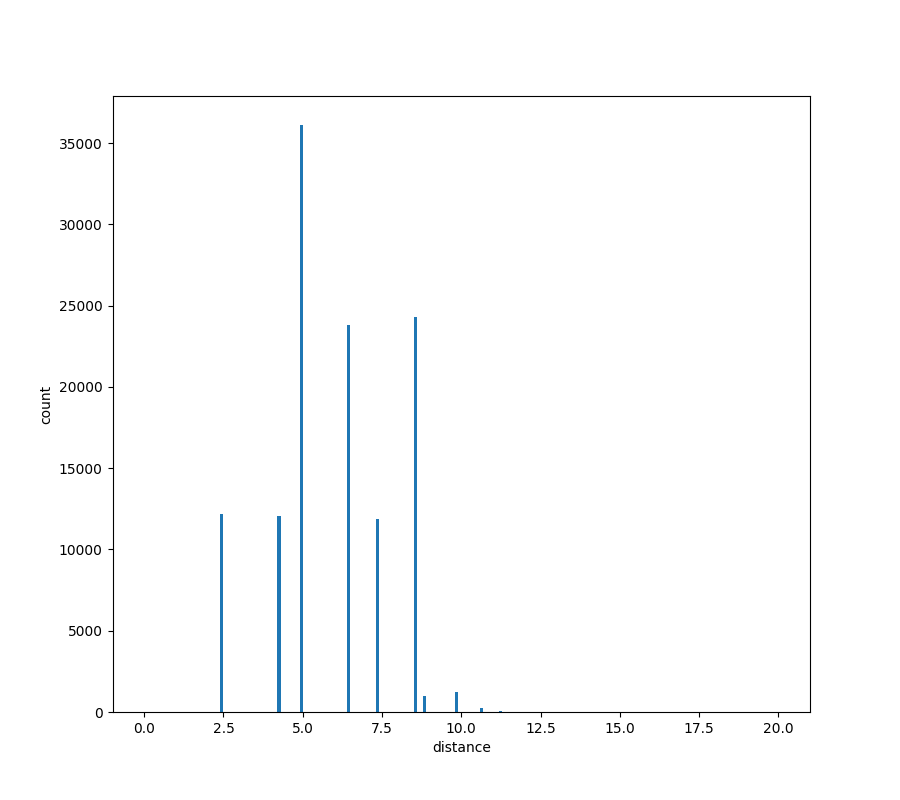

In [5]:
if figs[0] is not None:
	plt.close(figs[0])
figs[0], ax = plt.subplots(1, 1, figsize=(9, 8))
# ax.hist(small_pad_distances, bins=50, range=(4.90822, 4.90824))
ax.hist(small_pad_distances, bins=200, range=(0, 20))
ax.set_xlabel("distance")
ax.set_ylabel("count")
plt.show()

Now we know that neighboring small pads distance is about 2.5 in X direction, and about 4.2 in Y direction. The neighboring pads should be in opposite direction. We here define upward (angle on top, edge on bottom) as 0 and downward (angle to bottom and edge on top) as 1. But actually I don't know which is up and which is down, so I assum pad 24 (first pad) is upward (Actually I know it should be upward. If my assumption is wrong, I will edit this later.).

In [6]:
# assume the first small pad (should be 24) is upward
first_small = small_pad_pairs[0, 0]
pad_directions[first_small] = 0
print(first_small)

to_search = [first_small]
while len(to_search) > 0:
    filtered = small_pad_pairs.filter(pl.col("pad").is_in(to_search))
    to_search = []
    for row in filtered.iter_rows():
        pad = row[0]
        for i in range(4):
            neighbour = row[1][i]
            distance = row[2][i]
            if distance < 4.5:
                new_direction = 1 - pad_directions[pad]
                if pad_directions[neighbour] == -1:
                    pad_directions[neighbour] = new_direction
                    to_search.append(neighbour)
                elif pad_directions[neighbour] != new_direction:
                    print(f"Found error at pad {pad}")
            else:
                break

24


## Large pads

In [7]:
large_pads = pads.filter(pl.col("scale") == 1.0).select(["pad", "x", "y"])
print(len(large_pads))
large_pad_pairs = (
	large_pads
	.join(large_pads, how="cross")
	.filter(pl.col("pad") != pl.col("pad_right"))
	.select(
		"pad",
		"pad_right",
		(
			(
				(pl.col("x") - pl.col("x_right"))**2 +
				(pl.col("y") - pl.col("y_right"))**2
			)**0.5
		).alias("distance"),
	)
	.group_by("pad")
	.agg(pl.all().sort_by("distance").head(20))
	.sort("pad")
)
large_pad_distances = np.concatenate(large_pad_pairs["distance"].to_numpy())

4096


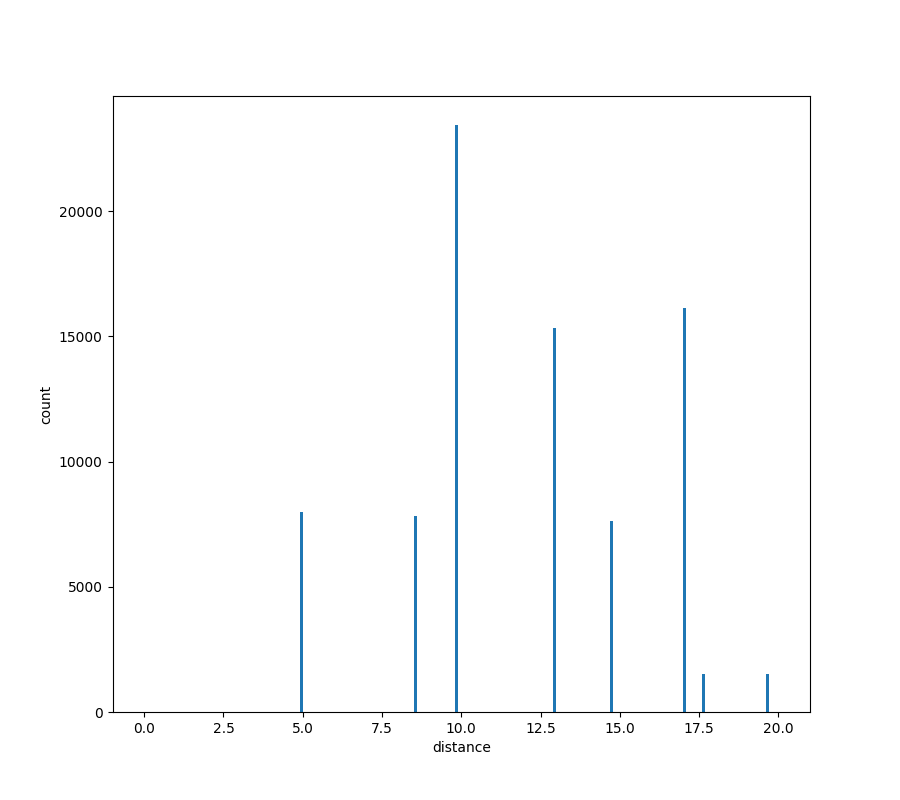

In [8]:
if figs[1] is not None:
	plt.close(figs[1])
figs[1], ax = plt.subplots(1, 1, figsize=(9, 8))
ax.hist(large_pad_distances, bins=200, range=(0, 20))
ax.set_xlabel("distance")
ax.set_ylabel("count")
plt.show()

It's similar to small pads, but with double distance.

In [9]:
# assume the first large pad (should be 0) is upward
first_large = large_pad_pairs[0, 0]
pad_directions[first_large] = 0
print(first_large)

to_search = [first_large]
while len(to_search) > 0:
    filtered = large_pad_pairs.filter(pl.col("pad").is_in(to_search))
    to_search = []
    for row in filtered.iter_rows():
        pad = row[0]
        for i in range(4):
            neighbour = row[1][i]
            distance = row[2][i]
            if distance < 9:
                new_direction = 1 - pad_directions[pad]
                if pad_directions[neighbour] == -1:
                    pad_directions[neighbour] = new_direction
                    to_search.append(neighbour)
                elif pad_directions[neighbour] != new_direction:
                    print(f"Found error at pad {pad}")
            else:
                break

0


## Write to file
At last, write the result to csv file.

In [10]:
directions_df = pl.DataFrame({
    "direction": pad_directions,
})
directions_df.write_csv("../config/padupdown.csv")